In [2]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pickle as pkl

In [3]:
#df_Nfd = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/total_mzcounts_sorted.csv')
df_new = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/New_data/new_data_MZB.csv')
df_ont = pd.read_excel('/home/apoorva/Desktop/work/MZ_analysis/data/New_data/20190412_MV_Bcellnumbers_ontogeny.xlsx', sheet_name='SPLEEN_Cell number')

# file_path = '/home/apoorva/Desktop/work/MZ_analysis/data/New_data/data_T2fits.json'
# import json

# if os.path.getsize(file_path) > 0:
#     with open(file_path, 'r') as f:
#         data = json.load(f)
# else:
#     raise EOFError("File is empty")

file_path = '/home/apoorva/Desktop/work/MZ_analysis/data/emperical_fit_T2.pkl'
if os.path.getsize(file_path) > 0:
    with open(file_path, 'rb') as f:
        data_neutral = pkl.load(f)
else:
    raise EOFError("File is empty")

# file_path1 = '/home/apoorva/Desktop/work/MZ_analysis/data/New output/SHM/new_fitted_T2.pkl'
# if os.path.getsize(file_path1) > 0:
#     with open(file_path1, 'rb') as f:
#         data_neutral = pkl.load(f)
# else:
#     raise EOFError("File is empty")
print(df_new.head(10))
print(df_ont.head(10))

                               Unnamed: 0  Age at BMT  Age at S1K  \
0  20181129_Bcells_SPLEEN_14d_001_019.fcs          74          88   
1  20181129_Bcells_SPLEEN_14d_002_020.fcs          41          88   
2      20181204_2-5wks_SPLEEN_001_018.fcs          74          92   
3      20181204_2-5wks_SPLEEN_002_019.fcs          41          59   
4        20181207_3wks_SPLEEN_001_048.fcs          74          95   
5        20181207_3wks_SPLEEN_002_049.fcs          41          62   
6        20181213_4wks_SPLEEN_001_024.fcs          74         102   
7        20181213_4wks_SPLEEN_002_025.fcs          41          69   
8   20181220_5wks_SPLEEN_CD1d_001_065.fcs          74         109   
9   20181220_5wks_SPLEEN_CD1d_002_066.fcs          41          76   

   Days postBMT  Lamis ID      total_FM     fd_FM  frac_Ki67+_FM_donor  \
0            14    832634  2.247009e+07  0.016125             0.441377   
1            14    848687  2.440681e+07  0.013667             0.485563   
2            18   

In [4]:
# Keep T1 AA4.1 in the data and remove the rest 

df_T1counts_Nfd = df_new.filter(items=['Lamis.ID', 'Days postBMT', 'Age at S1K', 'total_T2'])
df_T1counts_ont = df_ont.filter(items=['mouse', 'age.at.S1K', 'Transitional2'])
print(df_T1counts_Nfd.head(10))
print(df_T1counts_ont.head(10))

#save the data to a csv file

# df_T1counts_Nfd.to_csv('/home/apoorva/Desktop/work/MZ_analysis/data/T2counts_.csv', index=False)
# df_T1counts_ont.to_csv('/home/apoorva/Desktop/work/MZ_analysis/data/T2counts_ont.csv', index=False)



   Days postBMT  Age at S1K      total_T2
0            14          88  8.988324e+05
1            14          88  7.278377e+05
2            18          92  2.521597e+06
3            18          59  1.576299e+06
4            21          95  1.580845e+06
5            21          62  7.132940e+05
6            28         102  2.241694e+06
7            28          69  2.805271e+06
8            35         109  1.610491e+06
9            35          76  1.086125e+06
                              mouse  age.at.S1K  Transitional2
0    Samples_Spleen_002_d11_017.fcs          11   2.731288e+06
1    Samples_Spleen_003_d11_018.fcs          11   2.122800e+06
2    Samples_Spleen_004_d11_019.fcs          11   2.362542e+06
3    Samples_Spleen_005_d11_020.fcs          11   2.149343e+06
4    Samples_Spleen_006_d14_021.fcs          14   6.346286e+06
5    Samples_Spleen_007_d14_022.fcs          14   7.715313e+06
6    Samples_Spleen_008_d14_023.fcs          14   6.660167e+06
7    Samples_Spleen_009_d14_024.fc

/tmp/ipykernel_769526/3170775851.py:20: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 800)


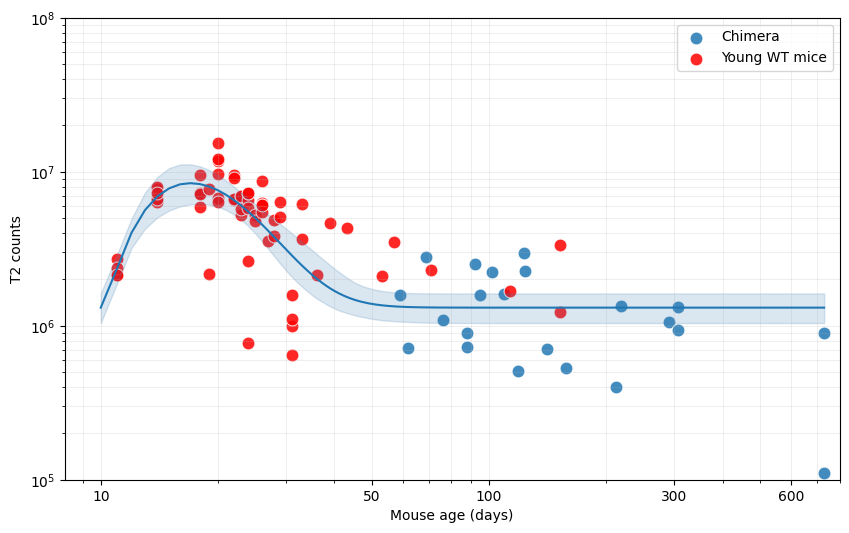

In [5]:
# def P(t):
#     theta_0 = np.exp(14)
#     nu = 0.156
#     n = 1.396
#     # return theta_0 * (1 + (t-11)**n * np.exp(-nu * (t-11)))
#     return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))
    

# Plot T1 AA4.1 counts
t_ev =np.array(np.arange(10,731,1))
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_T2', alpha=0.85 ,s=85, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='Transitional2', alpha=0.85, s=85, color = 'Red',label='Young WT mice', legend=False)
# plt.plot(np.arange(11, 800, 0.05), P(np.arange(11, 800, 0.05)))
plt.plot(t_ev, np.mean(data_neutral.T2_counts_pred, axis=0))
plt.fill_between(t_ev, np.quantile(data_neutral.T2_counts_pred, 0.025, axis=0), np.quantile(data_neutral.T2_counts_pred, 0.975, axis=0), color = 'steelblue', alpha=0.2)
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e5, 1e8)
plt.xlim(0, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 50,  100, 300, 600], [10, 50, 100, 300, 600])
plt.xlabel('Mouse age (days)')
plt.ylabel('T2 counts')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.show()


In [8]:
print(np.mean(data_neutral.theta_0))
print(np.mean(data_neutral.nu))
print(np.mean(data_neutral.n))

14.07933195
0.24946824108750001
1.7622314781250001


In [ ]:
def P(t):
    # theta_0 = np.exp(13.9591976)
    # nu = 0.349
    # n = 2.1701241
    # return theta_0 * (1 + t**n * np.exp(-nu * t))
    # theta_0 = np.exp(13.94)
    # nu = 0.395
    # n = 2.63
    # # return theta_0 * (1 + (t-11)**n * np.exp(-nu * (t-11)))
    # return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))
    theta_0 = np.exp(14.12)
    nu = 0.156
    n = 1.396
    # return theta_0 * (1 + (t-11)**n * np.exp(-nu * (t-11)))
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))
    # theta_0 = np.exp(13.8564)
    # nu = 0.395
    # n = 2.62564
    # # return theta_0 * (1 + (t-11)**n * np.exp(-nu * (t-11)))
    # return theta_0 * (1 + (t-11)**n * np.exp(-nu * (t-11)))
    # # theta_0 = np.exp(14)
    # nu = 0.2
    # n = 2.5
    # return theta_0 * (1 + t**n * np.exp(-nu * (t+10)))
   
 
# Define the ODE function
def ode_function(t, M, phi, rho, delta, P):
    dMdt = phi * P(t) - (delta - rho) * M
    return np.array(dMdt)


# Define the parameters as array

phi = data_neutral.phi  #Influx rate
delta = data_neutral.delta  #Death rate
rho = data_neutral.rho  #Division rate

# phi = 0.015 #Influx rate
# rho = 0.019  #Division rate
# delta = 0.028 #Death rate

#Initial conditions at time t=40
M0 = [12058]


t_ev = np.arange(11, 750, 0.001)

sol = np.zeros((len(data_neutral.phi), len(t_ev)))
for i in range(len(data_neutral.phi)):
    result = solve_ivp(ode_function, [11, 750], M0, t_eval= t_ev, args=(phi[i], rho[i], delta[i], P))
    sol[i, :] = result.y[0]

print(sol.shape)



KeyboardInterrupt: 

/tmp/ipykernel_1384140/2337953059.py:10: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 800)


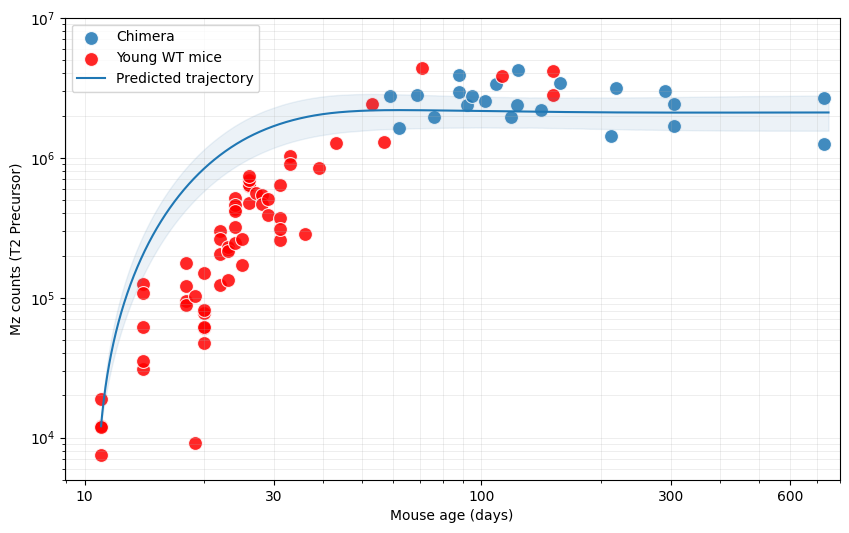

In [ ]:
# Plot the Mz counts
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85 ,s=100, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ', alpha=0.85, s=100, color= 'Red',label='Young WT mice', legend=False)
plt.plot(t_ev, np.mean(sol, axis=0), label='Predicted trajectory')
plt.fill_between(t_ev, np.quantile(sol, 0.025, axis=0), np.quantile(sol, 0.975, axis=0), color = 'steelblue',alpha=0.1)
plt.xscale('log')
plt.yscale('log')
plt.ylim(5*1e3, 1e7)
plt.xlim(0, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 30, 100, 300, 600], [10, 30, 100, 300, 600])
plt.xlabel('Mouse age (days)')
plt.ylabel('Mz counts (T2 Precursor)')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.show()



In [ ]:
def P(t):
    theta_0 = np.exp(14.12)
    nu = 0.156
    n = 1.396
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))

def phi(t):
    r_phi = 1.27
    phi = 0.022
    phi_var =  ((phi - 0.00156) / (1 + np.exp(-(r_phi) * (t-30)))) +0.00156
    return phi_var

# def phi(t):
#     if(t < 40):
#     #  r_phi = 0.02
#     #  phi = 0.014
#     #  phi_var =  phi * (1 - np.exp(-(r_phi) * (t-10)**1.7))
#      r_phi = 0.02
#      phi = 0.014
#      phi_var =  phi / (1 + np.exp(-(r_phi) * (t-10)))
#     return(phi_var)

# Define the ODE function
def ode_function(t, M, phi, P):
    dMdt = phi(t) * P(t) - 0.009 * M
    return np.array(dMdt)


# Define the parameters for T2 Precursor
# phi = 0.014


#Initial conditions at time t =40
M0 = [7450]


t_ev = np.arange(11, 750, 0.001)


sol_1 = solve_ivp(ode_function, [11,750], M0, t_eval=t_ev, args=(phi, P))
print(sol_1.y)


[[   7450.            7453.85903514    7457.72027988 ... 3310939.54783653
  3310939.57989605 3310939.61195543]]


/tmp/ipykernel_1384140/3299844580.py:9: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 800)


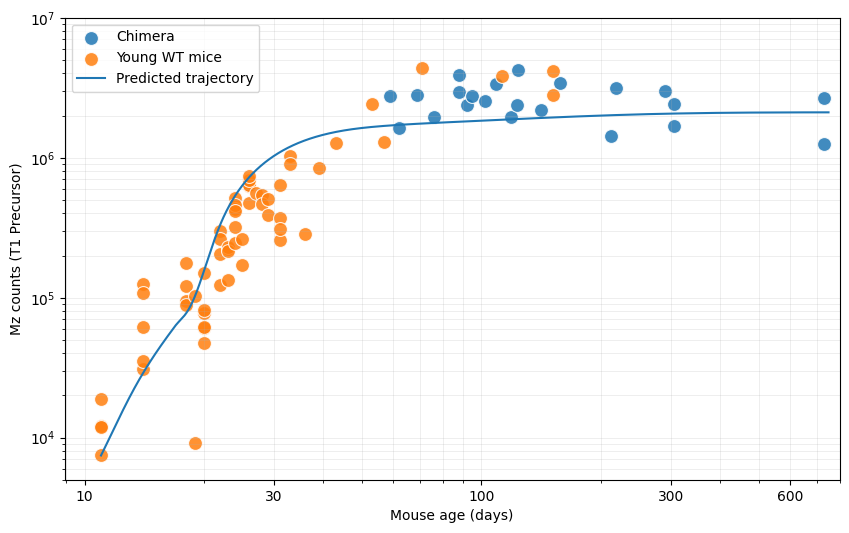

In [ ]:
# Plot the Mz counts
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85 ,s=100, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ', alpha=0.85, s=100, label='Young WT mice', legend=False)
plt.plot(t_ev, sol_1.y[0], label='Predicted trajectory')
plt.xscale('log')
plt.yscale('log')
plt.ylim(5*1e3, 1e7)
plt.xlim(0, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 30, 100, 300, 600], [10, 30, 100, 300, 600])
plt.xlabel('Mouse age (days)')
plt.ylabel('Mz counts (T1 Precursor)')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.show()

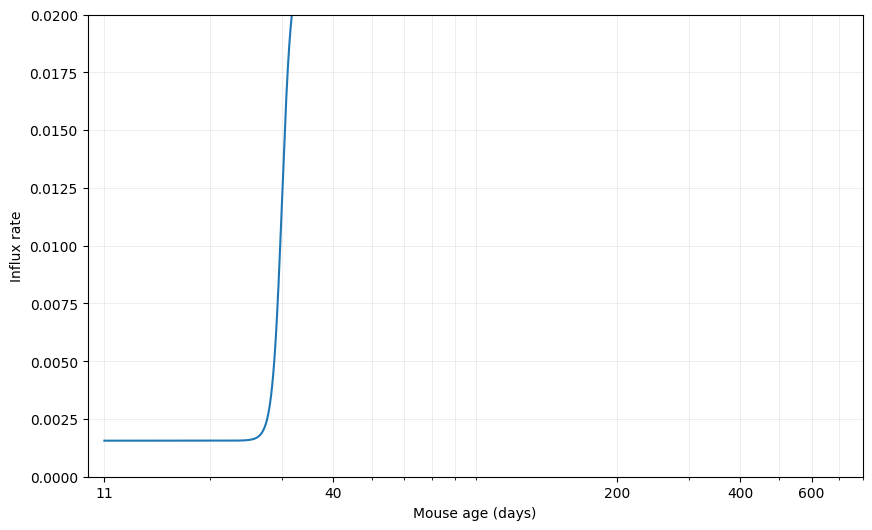

In [ ]:
#Daily Influx from T1 TO Mz
# Plot phi(t)

fig = plt.figure(figsize=(10, 6))
plt.plot(t_ev, phi(t_ev))
plt.xscale('log')
# plt.yscale('log')
plt.xlim(10, 800)
plt.ylim(0, 0.02)
plt.xticks([11, 40, 200, 400, 600], [11, 40, 200, 400, 600])
plt.xlabel('Mouse age (days)')
plt.ylabel('Influx rate')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.show()


In [ ]:
# def P(t):
#     # theta_0 = np.exp(13.9591976)
#     # nu = 0.349
#     # n = 2.1701241
#     # return theta_0 * (1 + t**n * np.exp(-nu * t))
#     theta_0 = np.exp(14.15)
#     nu = 0.27
#     n = 1.96
#     return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))

# def phi(t):
#     r_phi = 1.27
#     phi = 0.014
#     phi_var =  ((phi - 0.00156) / (1 + np.exp(-(r_phi) * (t-20)))) +0.00156
#     return phi_var

# # def phi(t):
# #     if(t < 40):
# #     #  r_phi = 0.02
# #     #  phi = 0.014
# #     #  phi_var =  phi * (1 - np.exp(-(r_phi) * (t-10)**1.7))
# #      r_phi = 0.02
# #      phi = 0.014
# #      phi_var =  phi / (1 + np.exp(-(r_phi) * (t-10)))
# #     return(phi_var)

# # Define the ODE function
# def ode_function(t, M, phi, P):
#     dMdt = phi(t) * P(t) - 0.009 * M
#     return np.array(dMdt)


# # Define the parameters for T2 Precursor
# # phi = 0.014


# #Initial conditions at time t =40
# M0 = [7450]


# t_ev = np.arange(11, 750, 0.001)


# sol_1 = solve_ivp(ode_function, [11,750], M0, t_eval=t_ev, args=(phi, P))
# print(sol_1.y)


[[   7450.            7453.7782648     7457.55930978 ... 2171671.81910584
  2171671.83523513 2171671.85136427]]


In [ ]:
# def P(t):
#     theta_0 = np.exp(13.95)
#     nu = 0.2976
#     n = 2.567
#     return theta_0 * (1 + t**n * np.exp(-nu * t))

# # Plot T1 AA4.1 counts

# fig = plt.figure(figsize=(10, 6))
# sns.scatterplot(data=df_Nfd, x='age.at.S1K', y='total_Transitional1_AA4.1', alpha=0.85 ,s=85, color= 'Red', label='Chimera', legend=False)
# sns.scatterplot(data=df_ont, x='age.at.S1K', y='T1 AA4.1+_total', alpha=0.85, s=85, label='Young WT mice', legend=False)
# plt.plot(np.arange(10, 800, 0.05), P(np.arange(10, 800, 0.05)), color='black')
# plt.xscale('log')
# plt.yscale('log')
# plt.ylim(1e5, 1e8)
# plt.xlim(0, 800)
# # plt.xticks([10, 30, 100, 300, 600])
# plt.xticks([10, 50,  100, 300, 600], [10, 50, 100, 300, 600])
# plt.xlabel('Mouse age (days)')
# plt.ylabel('Mz counts')
# plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
# plt.legend()
# plt.show()

In [ ]:
# def P(t):
#     # theta_0 = np.exp(13.9591976)
#     # nu = 0.349
#     # n = 2.1701241
#     # return theta_0 * (1 + t**n * np.exp(-nu * t))
#     theta_0 = np.exp(13.95)
#     nu = 0.365
#     n = 2.45
#     return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))
   
 
# # Define the ODE function
# def ode_function(t, M, phi, rho, delta, P):
#     dMdt = phi * P(t) - (delta - rho) * M
#     return np.array(dMdt)


# # Define the parameters for T2 Precursor
# phi = 0.015
# rho = 0.0082
# delta = 0.02

# #Initial conditions at time t =40
# M0 = [12580]


# t_ev = np.arange(11, 750, 0.001)


# sol_1 = solve_ivp(ode_function, [11,750], M0, t_eval=t_ev, args=(phi, rho, delta, P))
# print(sol_1.y)


In [ ]:
# # Plot the Mz counts
# fig = plt.figure(figsize=(10, 6))
# sns.scatterplot(data=df_Nfd, x='age.at.S1K', y='total_MZ', alpha=0.85 ,s=100, color= 'Red', label='Chimera', legend=False)
# sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ_total', alpha=0.85, s=100, label='Young WT mice', legend=False)
# plt.plot(t_ev, sol.y[0], label='Predicted trajectory')
# plt.xscale('log')
# plt.yscale('log')
# plt.ylim(5*1e3, 1e7)
# plt.xlim(0, 800)
# # plt.xticks([10, 30, 100, 300, 600])
# plt.xticks([10, 30, 100, 300, 600], [10, 30, 100, 300, 600])
# plt.xlabel('Mouse age (days)')
# plt.ylabel('Mz counts (T2 Precursor)')
# plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
# plt.legend()
# plt.show()
